# **Output-Explainable Computer Aided Diagnostic System for Pneumonia Detection using DenseNet-121 and Grad-CAM**

### **Introduction:**
A Computer-Aided Medical Diagnostic (CAD) System is a software system that assists
doctors and healthcare professionals in detecting and diagnosing diseases from medical data such
as X-rays, CT scans, MRI images, ultrasound images, laboratory reports, or patient symptoms.
An Output-Explainable CAD System goes one step further. Instead of only producing an
output such as “Disease detected” or “Normal”, it also explains why the system produced that
result. This makes the diagnostic system more transparent, interpretable, and useful to medical
professionals.
For example, if an AI model detects pneumonia in a chest X-ray, an explainable system can
highlight the lung regions that contributed most strongly to the prediction and provide a
confidence score and a short explanation.

Pneumonia is an acute infection and inflammation of the lungs, particularly affecting the alveoli (air sacs). It can be caused by bacteria, viruses, fungi, or other microorganisms. During pneumonia, the alveoli may fill with fluid, inflammatory exudate, and cellular debris, reducing normal gas exchange and potentially causing breathing difficulty.

Common symptoms include fever, cough, chest pain, fatigue, and shortness of breath. In severe cases, pneumonia can lead to hypoxemia and respiratory failure.

Chest X-ray is an important imaging modality for detecting pulmonary abnormalities associated with pneumonia. Typical radiological findings may include increased lung opacity, infiltrates, or consolidation. However, these findings are not specific to pneumonia and must be interpreted with clinical information.

Because chest X-rays are image-based and pneumonia can manifest through characteristic visual patterns, deep-learning models such as CNNs and DenseNet-121 can be used to assist in pneumonia classification, while explainable-AI methods can help identify the image regions influencing the model's prediction.

### **Problem Statement:**
Many modern medical diagnostic systems use Artificial Intelligence (AI) and Deep Learning
to achieve high diagnostic accuracy. However, complex models such as deep neural networks
often operate as &quot;black boxes.&quot; They may provide a prediction without clearly explaining the
reasoning behind it.

This creates several problems:

* Doctors may find it difficult to trust an unexplained AI prediction.
* Incorrect predictions can be difficult to identify.
* Medical professionals need evidence to support diagnostic decisions.
* Patients and healthcare institutions may require greater transparency.
* It is difficult to evaluate whether the model is focusing on medically relevant
regions.

Therefore, the proposed project aims to develop a Computer-Aided Pneumonia Diagnostic
System that produces both a diagnosis and an understandable explanation of that
diagnosis.

### **Objectives:**

The main objectives of the project are:
1. To develop an AI-based system for assisting medical diagnosis.
2. To process medical images or patient-related medical data.

3. To classify the input into appropriate diagnostic categories.
4. To provide a confidence/probability score with the prediction.
5. To explain the model&#39;s decision using explainable-AI techniques.
6. To identify important regions or features responsible for the prediction.
7. To provide an easy-to-understand diagnostic report.
8. To assist doctors rather than replace professional medical judgment.

### **Dataset Description:**

* **Dataset Name:** [Pediatric Chest X‑Ray Pneumonia — Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset?resource=download&select=test&utm_source=gemini)
* **Original Citation:** Kermany, D., et al., *Cell* 2018. (Collected at Guangzhou Women and Children’s Medical Center).
* **Task:** Binary image classification (**NORMAL** vs. **PNEUMONIA**).
* **Patient Cohort:** Pediatric anterior-posterior (AP) chest X-rays from patients aged 1–5.
* **Format & Specifications:** JPEG format, converted to 8-bit RGB. Total size is ~1.81 GB.
* **License:** CC BY 4.0


### Data Distribution & Splits

The dataset contains a total of **8,530 preprocessed, balanced frontal chest X-rays** (4,265 NORMAL and 4,265 PNEUMONIA):

| Split | NORMAL | PNEUMONIA | Total Images |
| --- | --- | --- | --- |
| **Train** | 3,400 | 3,400 | 6,800 |
| **Validation** | 850 | 850 | 1,700 |
| **Test** | 15 | 15 | 30 |
| **Total** | **4,265** | **4,265** | **8,530** |


### Key Highlights & Considerations

* **Balanced Class Distribution:** Created via controlled undersampling and augmentation to eliminate class imbalance issues common in original medical datasets.
* **Preprocessing Recommendations:** Resize input images to standard vision model dimensions (e.g., $224 \times 224$), and normalize pixel values using ImageNet mean and standard deviation.
* **Ethical & Clinical Note:** For research and benchmarking purposes only; not intended for direct clinical diagnosis due to single-center pediatric cohort limitations.

### **Proposed System Architecture**

The proposed Computer-Aided Diagnostic (CAD) system is organized into a modular end-to-end pipeline:

**Input $\rightarrow$ Preprocessing $\rightarrow$ AI Model $\rightarrow$ Prediction $\rightarrow$ Explainability Module $\rightarrow$ Diagnostic Report**


### **Detailed Component Breakdown**

* **1. Input**
* Accepts raw frontal pediatric chest X-ray images (in JPEG format) uploaded by the user via the Streamlit web dashboard sidebar.


* **2. Preprocessing**
* Converts images to standard RGB format.
* Resizes input images to standard vision dimensions ($224 \times 224$ pixels).
* Applies **DenseNet-121 feature scaling** (`preprocess_input`) to normalize pixel values into the $(-1.0, 1.0)$ range to match ImageNet pre-training standards.


* **3. AI Model**
* Utilizes a fine-tuned **DenseNet-121 backbone** pre-trained on ImageNet.
* Extracted feature representations pass through a custom classification head consisting of a **Global Average Pooling** layer, a **Dense(128)** layer with **Dropout(0.3)** regularization, and a **Softmax** output layer.


* **4. Prediction**
* Computes binary diagnostic classification probabilities (`NORMAL` vs. `PNEUMONIA`).
* Selects the highest-confidence class using `np.argmax()` and extracts the confidence percentage score.


* **5. Explainability Module (XAI)**
* Uses **Grad-CAM (Gradient-weighted Class Activation Mapping)** targeting the final feature layer (`conv5_block16_concat`).
* Calculates pooled gradients to weight feature map channels, producing a 2D activation matrix normalized between $0.0$ and $1.0$.
* Blends a thermal `JET` colormap overlay with the original X-ray image ($40\%$ heatmap + $60\%$ original) to visualize focal points.


* **6. Diagnostic Report**
* Displays the original X-ray alongside the Grad-CAM heatmap side-by-side using Streamlit columns (`st.columns(2)`).
* Automatically generates a structured text summary containing the predicted label, confidence percentage, visual interpretability analysis, and a clinical disclaimer.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [ ]:
from google.colab import files
import os

#  Uploading kaggle.json token from your computer
print("Please upload your kaggle.json file:")
files.upload()

#  Setting up Kaggle credentials directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#  Downloading the Chest X-Ray Pneumonia dataset
!kaggle datasets download -d yusufmurtaza01/chest-xray-pneumonia-balanced-dataset

#  Unzipping into Colab session storage
!unzip -q chest-xray-pneumonia-balanced-dataset.zip -d datasets/

print("\nDataset successfully extracted to ./datasets/\n")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset
License(s): CC0-1.0
chest-xray-pneumonia-balanced-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace datasets/test/NORMAL/IM-0006-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: [A]
error:  invalid response [[A]]
replace datasets/test/NORMAL/IM-0006-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

Dataset successfully extracted to ./datasets/



In [ ]:
# Resizing all the images
image_size= [224,224]

batch_size= 32
train_path= "/content/datasets/train"
valid_vath= "/content/datasets/val"
test_path= "/content/datasets/test"

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'datasets/train',
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# image_dataset_from_directory resizes images to $224 \times 224$ pixels, loads them in batches of 32, and converts class labels (NORMAL vs PNEUMONIA) into one-hot encoded vectors (label_mode='categorical').

Found 6800 files belonging to 2 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    'datasets/val',
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 1700 files belonging to 2 classes.


In [ ]:
# Applying DenseNet-specific scaling (-1 to 1 range matching ImageNet initialization)

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

# preprocess_input(x): Applies the exact normalization used when DenseNet-121 was originally trained on ImageNet. It converts raw RGB pixel values (ranging from 0 to 255) into a normalized floating-point range (typically -1.0 to 1.0).

Python map() vs. TensorFlow dataset.map():

Python Built-in map(f, iterable): Evaluates lazily and returns a standard Python iterator. You must wrap it in list() to see the computed values.

TensorFlow dataset.map(f): A specific method on tf.data.Dataset objects. It runs inside TensorFlow's graph engine across batches asynchronously (allowing operations like .prefetch() for faster GPU training).

When training a deep learning model, the process relies on two hardware components:

* **CPU:** Loads images from storage, decodes them, preprocesses them (e.g., scaling pixel values), and batches them.
* **GPU:** Runs matrix calculations and updates model weights.


**Without Prefetching (Sequential)**

Without `.prefetch()`, the process runs sequentially:

1. **CPU** loads Batch 1 $\rightarrow$ **GPU** sits idle waiting.
2. **GPU** trains on Batch 1 $\rightarrow$ **CPU** sits idle waiting.
3. **CPU** loads Batch 2 $\rightarrow$ **GPU** sits idle waiting.

This creates a bottleneck because your expensive GPU spends time doing nothing while the CPU prepares data.


**With `.prefetch()` (Parallel Pipeline)**

`.prefetch()` allows the CPU and GPU to work at the same time:

1. While the **GPU** is actively training on Batch 1...
2. The **CPU** simultaneously prepares Batch 2 in system memory (RAM).
3. When the GPU finishes Batch 1, Batch 2 is instantly ready for it—zero waiting time.

**Why `tf.data.AUTOTUNE`?**

Instead of manually guessing how many batches the CPU should prepare ahead of time (like `.prefetch(2)` or `.prefetch(5)`), `tf.data.AUTOTUNE` automatically:

* Monitors CPU speed, RAM availability, and GPU performance in real time.
* Dynamically adjusts the optimal buffer size so your GPU stays 100% busy without overwhelming system RAM.

  ### **DenseNet Architecture**               
                    
                    DenseNet-121
                         │
                Input: 224×224×3
                         │
                 7×7 Conv, 64
                   stride = 2
                         │
                 3×3 Max Pool
                   stride = 2
                         │
              56×56×64 feature maps
                         │
             ┌─────────────────────┐
             │    DENSE BLOCK 1    │
             │      6 layers       │
             │     growth = 32     │
             └─────────────────────┘
                         │
              1×1 Conv + 2×2 AvgPool
                         │
              28×28×128 feature maps
                         │
             ┌─────────────────────┐
             │    DENSE BLOCK 2    │
             │      12 layers      │
             │     growth = 32     │
             └─────────────────────┘
                         │
              1×1 Conv + 2×2 AvgPool
                         │
              14×14×256 feature maps
                         │
             ┌─────────────────────┐
             │    DENSE BLOCK 3    │
             │      24 layers      │
             │     growth = 32     │
             └─────────────────────┘
                         │
              1×1 Conv + 2×2 AvgPool
                         │
               7×7×512 feature maps
                         │
             ┌─────────────────────┐
             │    DENSE BLOCK 4    │
             │      16 layers      │
             │     growth = 32     │
             └─────────────────────┘
                         │
                    7×7×1024
                         │
              Global Average Pooling
                         │
                      1024
                         │
                 Fully Connected
                         │
                      Output


              
  | Part                 | Approx. parameters |
| -------------------- | -----------------: |
| Convolutional layers |            ~7.04 M |
| Batch Normalization  |            ~0.06 M |
| Final classifier     |            ~1.02 M |
| **Total**            |         **8.06 M** |


In [ ]:
# Initializing the base model

base_model= DenseNet121(
    input_shape= image_size+[3],
    weights= "imagenet",
    include_top= False
)
base_model.trainable = False  # Freezes all parameters within the DenseNet backbone. During Phase 1 training, backpropagation will only update the weights in our newly attached classifier head while leaving the base feature extractor untouched.

# input_shape=image_size + [3]: Expands [224, 224] to [224, 224, 3], specifying that the network expects input images of size $224 \times 224$ pixels with 3 color channels (RGB).

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Attaching Classifier Head (GlobalAveragePooling2D instead of Flatten)

inputs = tf.keras.Input(shape=image_size + [3])
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
# layers.GlobalAveragePooling2D(): Takes the 3D output tensor from DenseNet (e.g., shape 7 x 7 x 1024) and averages every spatial feature grid down to a single value per channel.
# (x): Passes the output of the base model into the pooling layer, reducing the feature map dimensions down to a 1D vector of length 1024
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
# Dropout(0.3) Layer: Applied directly after Dense(128). During training, it randomly zeroes out 30% of the 128 hidden activations on each forward pass to prevent co-adaptation and overfitting.
outputs = layers.Dense(2, activation='softmax')(x)

In our current notebook code, Batch Normalization wasn't included in our custom classifier head primarily to keep the baseline architecture simple, fast, and straightforward.

Here are the specific reasons why it wasn't strictly necessary for our initial setup:

Pre-Trained Features are Already Well-Conditioned: DenseNet121 already includes internal Batch Normalization layers within its pre-trained backbone blocks. By the time features reach GlobalAveragePooling2D, they are already reasonably normalized.

Small Custom Head (1 Hidden Layer): Our added head consists of only a single fully connected layer (Dense(128)). Internal covariate shift and exploding/vanishing gradients mainly affect very deep, multi-layer custom networks. With just one hidden layer, standard ReLU activation combined with Adam optimizer converges smoothly on its own.

Dropout is Already Providing Regularization: We included Dropout(0.3) directly after the Dense(128) layer, which acts as the primary regularizer against overfitting on the Pneumonia dataset.

Hyperparameter tuning could also be performed for better results.
Also we could also perform Abalation study.

In [ ]:
model= models.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,962 (27.35 MB)

 Trainable params: 131,458 (513.51 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# Phase 1 Training (Feature Extraction)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 136s 494ms/step - accuracy: 0.9265 - auc: 0.9797 - loss: 0.1819 - val_accuracy: 0.9576 - val_auc: 0.9910 - val_loss: 0.1171
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 71s 334ms/step - accuracy: 0.9587 - auc: 0.9924 - loss: 0.1075 - val_accuracy: 0.9594 - val_auc: 0.9911 - val_loss: 0.1211
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 64s 300ms/step - accuracy: 0.9651 - auc: 0.9941 - loss: 0.0932 - val_accuracy: 0.9582 - val_auc: 0.9920 - val_loss: 0.1112
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 66s 310ms/step - accuracy: 0.9657 - auc: 0.9951 - loss: 0.0860 - val_accuracy: 0.9471 - val_auc: 0.9859 - val_loss: 0.1554
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 82s 308ms/step - accuracy: 0.9701 - auc: 0.9955 - loss: 0.0819 - val_accuracy: 0.9535 - val_auc: 0.9891 - val_loss: 0.1355
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 71s 334ms/step - accuracy: 0.9694 - auc: 0.9961 - loss: 0.0774 - val_accuracy: 0.9618 - val_auc: 0.9930 - val_loss: 0.1042
Epoch 7/10
213/213 ━━

In [ ]:
# Phase 2 Fine-Tuning (Unfreezing Deeper Layers)

# Unfreezing base model layers
base_model.trainable = True
for layer in base_model.layers[:-30]:  # Keep earlier low-level layers frozen
    layer.trainable = False

# Defining Early Stopping & Learning Rate Reduction callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',         # To monitor validation loss
    patience=3,                 # Stop training if val_loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True,  # Automatically restore weights from the epoch with the best val_loss
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,                 # To reduce learning rate by 80% (1e-5 -> 2e-6) on plateau
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# ReduceLROnPlateau is a Keras callback that automatically reduces the learning rate when a monitored metric stops improving. It helps our optimizer settle into a local minimum when training hits a plateau, rather than overshooting it with a learning rate that is too large.

# Recompiling the model with a low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Low LR to protect weights
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Why Adam Works Well for Deep LearningAdaptive Step Sizes:
# Parameters with large or highly variable gradients receive smaller updates, while parameters with small or consistent gradients receive larger updates.
# Efficient Memory Usage: Requires storing only first and second moment vectors per parameter.Robust to Noisy Gradients:
# Ideal for mini-batch training on complex vision datasets like X-rays.
# Minimal Tuning Needed: Works exceptionally well out of the box with standard default hyperparameters ($\beta_1=0.9, \beta_2=0.999$)

# To fit the model with the callbacks parameter
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping, reduce_lr]  # Add callbacks list here
)

# Adam (Parameter-Level Scaling): Dynamically adjusts the learning rate for individual weights relative to each other based on their historical first (mean) and second (variance) moments.
# ReduceLROnPlateau (Global Scaling): Scales down the overall global step size for all parameters when the model's validation loss hits a plateau.

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 137s 481ms/step - accuracy: 0.9276 - auc: 0.9752 - loss: 0.2431 - val_accuracy: 0.9571 - val_auc: 0.9869 - val_loss: 0.1628 - learning_rate: 1.0000e-05
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 64s 302ms/step - accuracy: 0.9612 - auc: 0.9916 - loss: 0.1162 - val_accuracy: 0.9588 - val_auc: 0.9874 - val_loss: 0.1609 - learning_rate: 1.0000e-05
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 69s 321ms/step - accuracy: 0.9659 - auc: 0.9934 - loss: 0.1020 - val_accuracy: 0.9594 - val_auc: 0.9897 - val_loss: 0.1466 - learning_rate: 1.0000e-05
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 74s 345ms/step - accuracy: 0.9737 - auc: 0.9962 - loss: 0.0707 - val_accuracy: 0.9618 - val_auc: 0.9912 - val_loss: 0.1374 - learning_rate: 1.0000e-05
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 73s 341ms/step - accuracy: 0.9710 - auc: 0.9965 - loss: 0.0732 - val_accuracy: 0.9629 - val_auc: 0.9920 - val_loss: 0.1286 - learning_rate: 1.0000e-05
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 67s 

 Unfreezing layers from the start causes a severe issue called **catastrophic forgetting** (or gradient destruction).


**Why Unfreezing at the Beginning Fails**

1. **Random Head Weights:** At the start of training, our custom classifier head (`dense_1` and `dense_2`) has completely random weights.
2. **Massive Initial Loss:** Because the initial predictions are practically random guesses, the initial loss value is very high.
3. **Large Gradients:** Backpropagation calculates large loss gradients and passes them all the way back through the entire network.
4. **Wiping Out Pre-trained Features:** These large, unstable gradients overwrite and destroy the carefully pre-trained ImageNet weights in DenseNet121 before the classifier head even learns basic patterns.


**The Correct Strategy (Why 2 Phases Work)**

* **Phase 1 (Warm-up):** Keeping the base model frozen acts as a protective wall. It gives the newly added classifier head time to converge and stabilize its weights without corrupting DenseNet's feature representations.
* **Phase 2 (Fine-Tuning):** Once the classifier head is already producing reasonable predictions and low loss gradients, we can safely unfreeze deeper layers with a very small learning rate (`1e-5`) to fine-tune the high-level features for chest X-rays.

In [ ]:
# Saving locally in Colab runtime

model.save('densenet121_chest_xray.keras')
print("Model saved locally as 'densenet121_chest_xray.keras'")

Model saved locally as 'densenet121_chest_xray.keras'


In [ ]:
from google.colab import drive

# Mounting Google Drive
drive.mount('/content/drive')

# Saving the model directly to a folder in my Drive
model.save('/content/drive/MyDrive/densenet121_chest_xray.keras')
print("Model saved successfully to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved successfully to Google Drive!


Found 30 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step

Accuracy: 96.67% | Sensitivity: 100.00% | Specificity: 93.33% | ROC-AUC: 1.0000


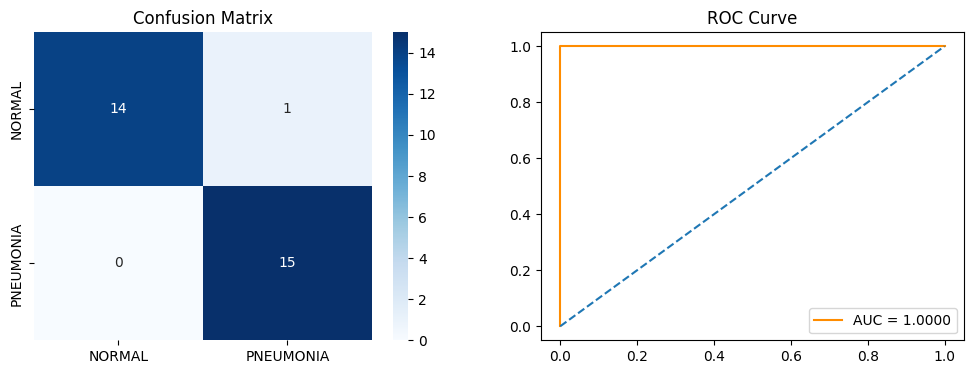

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Loading Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    'datasets/test',
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

class_names = test_ds.class_names
test_ds_preprocessed = test_ds.map(lambda x, y: (preprocess_input(x), y))

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])   # is used to convert one-hot encoded label vectors into single integer class labels.

# Inference
model = tf.keras.models.load_model('densenet121_chest_xray.keras')
y_pred_probs = model.predict(test_ds_preprocessed)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
roc_auc = roc_auc_score(y_true, y_pred_probs[:, 1])

cm = confusion_matrix(y_true, y_pred_classes)
tn, fp, fn, tp = cm.ravel()    # .ravel() flattens a multi-dimensional array into a continuous 1D array.
specificity = tn / (tn + fp)

print(f"\nAccuracy: {accuracy*100:.2f}% | Sensitivity: {recall*100:.2f}% | Specificity: {specificity*100:.2f}% | ROC-AUC: {roc_auc:.4f}")

# Visuals
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])    # Ignores the third value returned by roc_curve (the decision thresholds array), as it is not needed for plotting the curve.
ax[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.4f}')
ax[1].plot([0, 1], [0, 1], linestyle='--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.show()

### **Model Performance Evaluation**:

The proposed **DenseNet-121-based pneumonia detection system** was evaluated using a confusion matrix and a Receiver Operating Characteristic (ROC) curve. The test set contained **30 chest X-ray images**, comprising 15 NORMAL and 15 PNEUMONIA cases.

The confusion matrix was:

| Actual / Predicted |  NORMAL | PNEUMONIA |
| ------------------ | ------: | --------: |
| **NORMAL**         | 14 (TN) |    1 (FP) |
| **PNEUMONIA**      |  0 (FN) |   15 (TP) |

#### **Performance Metrics**

**1. Accuracy**

Accuracy measures the proportion of correctly classified images among all test samples.

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
=\frac{15+14}{15+14+1+0}
=\frac{29}{30}
=\boxed{96.67\%}
$$

**2. Sensitivity (Recall)**

Sensitivity measures the model's ability to correctly identify pneumonia cases.

$$
Sensitivity=\frac{TP}{TP+FN}
$$

$$
=\frac{15}{15+0}
=\boxed{100\%}
$$

**3. Specificity**

Specificity measures the model's ability to correctly identify NORMAL cases.

$$
Specificity=\frac{TN}{TN+FP}
$$

$$
=\frac{14}{14+1}
=\boxed{93.33\%}
$$

**4. Precision**

Precision represents the proportion of images predicted as PNEUMONIA that were actually pneumonia cases.

$$
Precision=\frac{TP}{TP+FP}
$$

$$
=\frac{15}{15+1}
=\boxed{93.75\%}
$$

**5. F1-Score**

The F1-score provides the harmonic mean of precision and recall.

$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$

$$
=2\times\frac{0.9375\times1.0}{0.9375+1.0}
$$

$$
=\boxed{96.77\%}
$$

### **ROC-AUC**

The Receiver Operating Characteristic (ROC) curve evaluates the model's discrimination capability across different classification thresholds. The **Area Under the ROC Curve (AUC)** obtained was:

$$
\boxed{AUC=1.00}
$$

An AUC of 1.00 indicates perfect class separation **on this particular test set**.

#### **Interpretation**

The model achieved **96.67% accuracy**, **100% sensitivity**, **93.33% specificity**, **93.75% precision**, and an **F1-score of 96.77%** on the evaluated test set. The absence of false negatives indicates that all 15 pneumonia cases were correctly identified. However, because the evaluation was performed on only **30 test images**, the results should be interpreted cautiously. A larger, independent, and diverse dataset would be required to establish the model's robustness and clinical generalizability.


In [ ]:
%%writefile app.py    # This script builds a Streamlit web dashboard for chest X-ray diagnosis with Grad-CAM visual explainability.

import streamlit as st    # In Python web development (specifically with Streamlit), import streamlit as st is imported to build interactive web dashboards and deployment interfaces directly from Python code.
import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input
import numpy as np
import cv2    # This script builds a Streamlit web dashboard for chest X-ray diagnosis with Grad-CAM visual explainability.
from PIL import Image     # In Python image processing and deep learning workflows, from PIL import Image imports the core Image module from the Pillow library (Python Imaging Library)

st.set_page_config(page_title="Output-Explainable CAD System", layout="wide")

st.title(" Output-Explainable Computer-Aided Medical Diagnostic System")
st.write("Deep Learning Diagnostic Support with Grad-CAM Visual Interpretability")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('densenet121_chest_xray.keras')

model = load_model()

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block16_concat', pred_index=None):
    base_model = model.get_layer("densenet121")
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_heatmap(img_pil, heatmap, alpha=0.4):
    img = np.array(img_pil)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return np.uint8(heatmap * alpha + img * (1 - alpha))

uploaded_file = st.sidebar.file_uploader("Upload Chest X-Ray Image", type=["jpg", "jpeg", "png"])
class_labels = ['NORMAL', 'PNEUMONIA']

if uploaded_file is not None:
    raw_img = Image.open(uploaded_file).convert('RGB')
    img_resized = raw_img.resize((224, 224))
    img_array = np.array(img_resized, dtype=np.float32)
    preprocessed_img = preprocess_input(np.expand_dims(img_array, axis=0))

    preds = model.predict(preprocessed_img)
    pred_class_idx = np.argmax(preds[0])
    pred_label = class_labels[pred_class_idx]
    confidence = preds[0][pred_class_idx] * 100      # confidence represents the predicted probability assigned to a specific class (such as PNEUMONIA or NORMAL) by the model's final layer.

    heatmap = make_gradcam_heatmap(preprocessed_img, model, pred_index=pred_class_idx)
    gradcam_overlay = overlay_heatmap(raw_img, heatmap)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Original Chest X-Ray")
        st.image(raw_img, use_container_width=True)

    with col2:
        st.subheader("X-Ray + Grad-CAM Heatmap")
        st.image(gradcam_overlay, use_container_width=True)

    st.markdown("---")
    st.subheader("📋 Explainable Diagnostic Report")
    st.code(f"""
===================================================
             EXPLAINABLE CAD DIAGNOSTIC REPORT
===================================================
Input Type:         Chest X-Ray
Diagnostic Result:  {pred_label}
Model Confidence:   {confidence:.2f}%

EXPLANATION (XAI):
The highlighted red/warm regions on the Grad-CAM
heatmap identify the anatomical zones that contributed
most strongly to the model's prediction.

INTERPRETATION:
{"Abnormal opacities/patterns were detected in highlighted regions." if pred_label == "PNEUMONIA" else "No significant abnormal localized opacities were detected."}

DISCLAIMER:
This output is generated by an AI decision-support
system to assist qualified healthcare professionals.
It does NOT constitute a standalone clinical diagnosis.
===================================================
""", language="text")

Overwriting app.py


In [ ]:
import subprocess
import time

# Installing streamlit if needed
!pip install -q streamlit

# Running Streamlit in the background
subprocess.Popen(["streamlit", "run", "app.py"])
time.sleep(3)

# Downloading and launching Cloudflare Tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1
!cloudflared tunnel --url http://localhost:8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 77.9 MB/s eta 0:00:00
2026-09-14T21:06:49Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-14T21:06:49Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-14T21:06:53Z INF +--------------------------------------------------------------------------------------------+
2026-09-14T21:06:53Z INF |  Your quick Tunn

### **Working of the System:**

The **Output-Explainable Computer-Aided Diagnostic System for Pneumonia Detection using DenseNet-121 and Grad-CAM** operates through a sequence of image preprocessing, deep-learning-based classification, and visual explanation steps:

1. **Medical Image Input:** The user uploads a **chest X-ray image** to the system for pneumonia analysis.

2. **Image Preprocessing:** The uploaded X-ray is checked and preprocessed into a format suitable for the trained DenseNet-121 model. The preprocessing ensures that the input image is compatible with the model's expected input dimensions and representation.

3. **Feature Extraction using DenseNet-121:** The preprocessed chest X-ray is passed through the trained **DenseNet-121** network, which extracts hierarchical visual features from the image through its convolutional and densely connected layers.

4. **Pneumonia Classification:** The extracted features are passed to the classification layer, which produces prediction scores/probabilities for the two diagnostic classes: **NORMAL** and **PNEUMONIA**.

5. **Prediction and Confidence:** The class with the highest predicted probability is selected as the final model prediction. The corresponding probability is presented as the model's **confidence score**.

6. **Explainability using Grad-CAM:** The prediction is further analyzed using **Gradient-weighted Class Activation Mapping (Grad-CAM)**. Grad-CAM uses gradients associated with the predicted class to determine the spatial regions of the chest X-ray that contributed most strongly to the model's output.

7. **Generation of Heatmap:** A **Grad-CAM heatmap** is generated and overlaid on the original chest X-ray, providing a visual indication of the regions that influenced the prediction.

8. **Output Display:** The system presents the **input chest X-ray, predicted class, confidence score, and Grad-CAM visualization** to provide both the classification result and an interpretable representation of the model's decision.

9. **Diagnostic Assistance:** The combined prediction and visual explanation can assist in reviewing the model's output. However, the system is intended as a **computer-aided decision-support/research tool and not as a replacement for qualified medical professionals**.

### System Workflow

```text
Chest X-ray Image
        │
        ▼
Image Preprocessing
        │
        ▼
   DenseNet-121
        │
        ▼
Feature Extraction
        │
        ▼
Classification
        │
        ▼
NORMAL / PNEUMONIA
        │
        ├──────────────► Confidence Score
        │
        ▼
     Grad-CAM
        │
        ▼
   Heatmap Generation
        │
        ▼
Original X-ray + Prediction
+ Confidence + Grad-CAM
        │
        ▼
Explainable Diagnostic Assistance
```

**Core pipeline:**

$$
\boxed{\text{Chest X-ray}\rightarrow\text{Preprocessing}\rightarrow\text{DenseNet-121}\rightarrow\text{Prediction}\rightarrow\text{Grad-CAM}\rightarrow\text{Explainable Output}}
$$


### **Advantages:**
* Provides AI-assisted medical diagnosis.
* Makes predictions more transparent.
* Helps doctors understand model behavior.
* Highlights potentially relevant image regions.

* Can reduce the time required for preliminary screening.
* Provides consistent computer-assisted analysis.
* Can be useful as a research and educational platform.

### **Limitations:**
* AI predictions can be incorrect.
* Explainability methods do not guarantee causal medical reasoning.
* Performance depends heavily on the quality and representativeness of the
dataset.
* A model trained on one hospital or population may not generalize to another.
* Medical images can contain sensitive patient information.
* The system should not independently make clinical decisions without appropriate
validation and professional oversight.

### **Future Scope:**

The system can be extended by:
* Supporting multiple diseases.
* Using multimodal data such as images, symptoms, and laboratory results.
* Adding patient-history analysis.
* Developing a mobile application.
* Generating structured medical reports.
* Adding uncertainty estimation and calibration.
* Comparing explanations from multiple XAI methods.
* Evaluating the system with clinicians.
* Integrating with appropriate hospital information systems after rigorous validation
and regulatory review.
* Incorporating Abalation Study and Hyperparameter Tuning.

### **Conclusion:**
The Output-Explainable Computer-Aided Diagnostic System for Pneumonia Detection integrates DenseNet-121 with Grad-CAM to provide both a pneumonia prediction and a visual explanation of the regions contributing to that prediction. DenseNet-121 enables the extraction of hierarchical and discriminative features from chest X-ray images, while Grad-CAM generates class-specific activation maps that highlight the areas of the image most influential to the model's decision.

The system therefore goes beyond simply producing a binary prediction by providing an interpretable visual representation of the model's reasoning. This is particularly important in medical image analysis, where understanding whether the model is attending to clinically relevant pulmonary regions is as important as evaluating its predictive performance.

Nevertheless, the proposed system should be regarded as a research and decision-support tool rather than an autonomous diagnostic system. Its practical clinical applicability would require extensive validation on diverse and representative patient populations, assessment of dataset and model bias, calibration of predictive confidence, protection of patient privacy, and compliance with relevant medical and regulatory standards. Ultimately, the integration of deep learning with explainability provides a promising framework for developing more transparent and accountable AI-assisted systems for pneumonia screening.